# GrandChase Atlas

A read-only notebook for browsing the captured GrandChase database without digging through raw HTML, CSV dumps, or rebuild scripts.

Run the next three code cells in order:

1. Load the styled browser and cached SQLite data.
2. Open the overview dashboard for roster, variants, sections, and patch coverage.
3. Search by hero, keyword, section, or variant type until you find the exact coefficients, cooldowns, buffs, debuffs, and patch notes you need.

The data shown here comes from the current local database and stored Namu captures only. No live scraping happens inside this notebook.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 320)
plt.rcParams["figure.figsize"] = (13, 6)
plt.rcParams["axes.facecolor"] = "#fffaf1"
plt.rcParams["figure.facecolor"] = "#f6f1e7"

project_candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    candidate
    for candidate in project_candidates
    if (candidate / "data" / "processed" / "grandchase.db").exists()
)
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DB_PATH = PROCESSED_DIR / "grandchase.db"

if not DB_PATH.exists():
    raise FileNotFoundError(
        "Missing data/processed/grandchase.db. Run `bash scripts/run_pipeline.sh` first."
    )

conn = sqlite3.connect(DB_PATH)

display(
    HTML(
        """
        <style>
            .gc-banner {
                background: linear-gradient(135deg, #17324d 0%, #0f6c74 45%, #f0b44c 100%);
                color: #f8f3e8;
                padding: 22px 24px;
                border-radius: 22px;
                margin: 10px 0 18px 0;
                box-shadow: 0 20px 48px rgba(23, 50, 77, 0.18);
                font-family: "Avenir Next", "IBM Plex Sans", "Segoe UI", sans-serif;
            }
            .gc-banner h2 {
                margin: 0 0 6px 0;
                font-size: 1.85rem;
                font-weight: 750;
                letter-spacing: 0.01em;
            }
            .gc-banner p {
                margin: 0;
                max-width: 78ch;
                line-height: 1.55;
                color: rgba(248, 243, 232, 0.92);
            }
            .gc-card-grid {
                display: grid;
                grid-template-columns: repeat(auto-fit, minmax(180px, 1fr));
                gap: 12px;
                margin: 14px 0 22px 0;
            }
            .gc-card {
                background: linear-gradient(180deg, #fffaf1 0%, #f5ecdd 100%);
                border: 1px solid #e6d5bc;
                border-radius: 18px;
                padding: 14px 16px;
                box-shadow: 0 10px 28px rgba(98, 71, 45, 0.08);
                font-family: "Avenir Next", "IBM Plex Sans", "Segoe UI", sans-serif;
            }
            .gc-label {
                font-size: 0.72rem;
                text-transform: uppercase;
                letter-spacing: 0.08em;
                color: #8a6542;
                margin-bottom: 8px;
            }
            .gc-value {
                font-size: 1.85rem;
                font-weight: 800;
                color: #17324d;
                line-height: 1.08;
            }
            .gc-meta {
                margin-top: 6px;
                color: #5b6672;
                font-size: 0.92rem;
                line-height: 1.4;
            }
        </style>
        """
    )
)


def sql(query: str, params: tuple | list | None = None) -> pd.DataFrame:
    frame = pd.read_sql_query(query, conn, params=params or ())
    return frame.fillna("")


def gc_cards(title: str, subtitle: str, items: list[tuple[str, object, str]]) -> None:
    cards = "".join(
        f"<div class='gc-card'><div class='gc-label'>{label}</div><div class='gc-value'>{value}</div><div class='gc-meta'>{meta}</div></div>"
        for label, value, meta in items
    )
    display(
        HTML(
            f"<div class='gc-banner'><h2>{title}</h2><p>{subtitle}</p></div><div class='gc-card-grid'>{cards}</div>"
        )
    )


def gc_style(frame: pd.DataFrame, wide_columns: tuple[str, ...] = ()):
    if frame.empty:
        return frame

    styled = (
        frame.style.hide(axis="index")
        .set_table_styles(
            [
                {
                    "selector": "table",
                    "props": [
                        ("border-collapse", "separate"),
                        ("border-spacing", "0 6px"),
                        ("width", "100%"),
                        ("font-size", "0.97rem"),
                    ],
                },
                {
                    "selector": "thead th",
                    "props": [
                        ("background", "#17324d"),
                        ("color", "#f7f3e9"),
                        ("padding", "10px 12px"),
                        ("border", "0"),
                        ("text-align", "left"),
                    ],
                },
                {
                    "selector": "tbody td",
                    "props": [
                        ("background", "#fffaf1"),
                        ("padding", "10px 12px"),
                        ("border-top", "1px solid #eadbc4"),
                        ("border-bottom", "1px solid #eadbc4"),
                        ("color", "#203040"),
                        ("vertical-align", "top"),
                    ],
                },
            ]
        )
    )

    if wide_columns:
        styled = styled.set_properties(
            subset=list(wide_columns),
            **{"white-space": "pre-wrap", "max-width": "560px"},
        )

    numeric_columns = [
        column for column in frame.columns if pd.api.types.is_numeric_dtype(frame[column])
    ]
    if numeric_columns:
        styled = styled.background_gradient(subset=numeric_columns, cmap="YlOrBr")
    return styled


heroes_df = sql(
    """
    WITH mode_pivot AS (
        SELECT
            hero_id,
            MAX(CASE WHEN mode = 'adventure' THEN tier_letter END) AS adventure_tier,
            MAX(CASE WHEN mode = 'battle' THEN tier_letter END) AS battle_tier,
            MAX(CASE WHEN mode = 'boss' THEN tier_letter END) AS boss_tier
        FROM hero_modes
        GROUP BY hero_id
    )
    SELECT
        h.hero_id,
        h.name_en,
        h.name_ko,
        h.role,
        h.rarity,
        h.sources,
        mp.adventure_tier,
        mp.battle_tier,
        mp.boss_tier,
        s.base_score,
        s.rarity_adjusted,
        s.final_meta_score,
        s.meta_rank
    FROM heroes h
    LEFT JOIN mode_pivot mp USING (hero_id)
    LEFT JOIN hero_meta_scores s USING (hero_id)
    ORDER BY s.meta_rank, h.name_en
    """
)

variants_df = sql(
    """
    SELECT
        hv.variant_id,
        h.name_en,
        h.name_ko,
        h.role,
        hv.variant_name_en,
        hv.variant_kind,
        hv.variant_suffix,
        hv.availability_marker,
        hv.source_title AS variant_title,
        hv.note_excerpt
    FROM hero_variants hv
    JOIN heroes h ON h.hero_id = hv.hero_id
    ORDER BY h.name_en, hv.variant_kind, hv.variant_name_en
    """
)

section_index_df = sql(
    """
    SELECT
        h.name_en,
        h.name_ko,
        hv.variant_id,
        hv.variant_kind,
        hv.variant_name_en,
        hv.source_title AS variant_title,
        hv.variant_suffix,
        hvs.heading_level,
        hvs.heading_title,
        hvs.section_path,
        hvs.content,
        hvs.source_page
    FROM hero_variant_sections hvs
    JOIN hero_variants hv ON hv.variant_id = hvs.variant_id
    JOIN heroes h ON h.hero_id = hv.hero_id
    ORDER BY h.name_en, hv.variant_kind, hvs.heading_level, hvs.heading_title
    """
)

skill_index_df = sql(
    """
    SELECT
        h.name_en,
        hv.variant_kind,
        hv.source_title AS variant_title,
        hvs.section_title,
        hvs.skill_stage,
        hvs.skill_type,
        hvs.skill_name,
        hvs.description
    FROM hero_variant_skills hvs
    JOIN hero_variants hv ON hv.variant_id = hvs.variant_id
    JOIN heroes h ON h.hero_id = hv.hero_id
    ORDER BY h.name_en, hv.variant_kind, hvs.skill_stage, hvs.skill_name
    """
)

feature_index_df = sql(
    """
    SELECT
        h.name_en,
        hv.variant_kind,
        hv.source_title AS variant_title,
        hvf.feature_key,
        hvf.feature_value
    FROM hero_variant_features hvf
    JOIN hero_variants hv ON hv.variant_id = hvf.variant_id
    JOIN heroes h ON h.hero_id = hv.hero_id
    ORDER BY h.name_en, hv.variant_kind, hvf.feature_key
    """
)

patch_index_df = section_index_df[
    section_index_df["section_path"].str.contains("Patch Details", case=False, na=False)
] .copy()

top_heroes_df = heroes_df[
    ["meta_rank", "name_en", "name_ko", "role", "rarity", "final_meta_score"]
] .head(15).copy()

role_summary_df = (
    heroes_df.groupby("role", dropna=False)
    .agg(
        hero_count=("hero_id", "count"),
        avg_meta_score=("final_meta_score", "mean"),
        best_meta_score=("final_meta_score", "max"),
    )
    .reset_index()
    .sort_values("avg_meta_score", ascending=False)
    .reset_index(drop=True)
)
role_summary_df[["avg_meta_score", "best_meta_score"]] = role_summary_df[[
    "avg_meta_score",
    "best_meta_score",
]].round(2)

mode_breakdown_df = sql(
    """
    SELECT
        hm.mode,
        h.name_en,
        h.role,
        hm.tier_letter,
        hm.tier_numeric,
        s.final_meta_score
    FROM hero_modes hm
    JOIN heroes h USING (hero_id)
    JOIN hero_meta_scores s USING (hero_id)
    ORDER BY hm.mode, hm.tier_numeric DESC, s.final_meta_score DESC, h.name_en
    """
)

gc_cards(
    "GrandChase Atlas Ready",
    "This notebook is now operating as a read-only browser over the stored SQLite outputs and full page-section capture. Use the next cells to scan the meta, search text, and open a hero dossier without touching the pipeline.",
    [
        ("Heroes", heroes_df["name_en"].nunique(), "unified roster in SQLite"),
        ("Variants", variants_df["variant_id"].nunique(), "captured hero / form pages"),
        ("Sections", len(section_index_df), "full heading blocks from Namu pages"),
        ("Skill Rows", len(skill_index_df), "parsed skill entries"),
        ("Patch Blocks", len(patch_index_df), "captured patch-note sections"),
        ("Feature Flags", len(feature_index_df), "page capability markers"),
    ],
)

print(f"Connected to {DB_PATH}")

Connected to /Users/gunnarhostetler/Documents/GitHub/GCDC/data/processed/grandchase.db


In [2]:
# Make variant markers visible in notebook tables.
def format_variant_kind_label(variant_kind: str, variant_suffix: str = "") -> str:
    kind_label = {"base": "Base", "former": "Former", "special": "Special"}.get(
        str(variant_kind).strip(),
        str(variant_kind).replace("_", " ").title() or "Variant",
    )
    suffix = str(variant_suffix).strip()
    return f"{kind_label} ({suffix})" if suffix else kind_label


def apply_variant_display_columns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    lookup_frame = variants_df[
        ["variant_title", "variant_name_en", "variant_kind", "variant_suffix"]
    ].drop_duplicates()
    name_lookup = lookup_frame.set_index(["variant_title", "variant_kind"])[
        "variant_name_en"
    ].to_dict()
    suffix_lookup = lookup_frame.set_index(["variant_title", "variant_kind"])[
        "variant_suffix"
    ].to_dict()

    if "variant_name_en" not in result.columns:
        result["variant_name_en"] = [
            name_lookup.get((title, kind), title)
            for title, kind in zip(result["variant_title"], result["variant_kind"])
        ]
    else:
        result["variant_name_en"] = [
            str(name).strip() or name_lookup.get((title, kind), title)
            for name, title, kind in zip(
                result["variant_name_en"],
                result["variant_title"],
                result["variant_kind"],
            )
        ]

    if "variant_suffix" not in result.columns:
        result["variant_suffix"] = [
            suffix_lookup.get((title, kind), "")
            for title, kind in zip(result["variant_title"], result["variant_kind"])
        ]
    else:
        result["variant_suffix"] = [
            str(suffix).strip() or suffix_lookup.get((title, kind), "")
            for suffix, title, kind in zip(
                result["variant_suffix"],
                result["variant_title"],
                result["variant_kind"],
            )
        ]

    result["variant_kind_label"] = [
        format_variant_kind_label(kind, suffix)
        for kind, suffix in zip(result["variant_kind"], result["variant_suffix"])
    ]
    result["variant_label"] = [
        f"{name} · {kind_label}"
        for name, kind_label in zip(
            result["variant_name_en"],
            result["variant_kind_label"],
        )
    ]
    return result


variants_df = apply_variant_display_columns(variants_df)
section_index_df = apply_variant_display_columns(section_index_df)
skill_index_df = apply_variant_display_columns(skill_index_df)
feature_index_df = apply_variant_display_columns(feature_index_df)

display(
    HTML(
        "<p><strong>Variant labels enabled.</strong> Notebook tables now show Base, Former (T), and Special (S) when the source provides them.</p>"
    )
)

## 2. Overview Dashboard

This section gives you the fast read: who is strong, how much variant coverage exists, and where the captured page content is concentrated. It is meant to answer “what should I click into next?” without making you sift through raw exports.

meta_rank,name_en,name_ko,role,rarity,final_meta_score
1,Amy,에이미,Healer,SS,6.900000
2,Ley,레이,Mage,SS,6.900000
3,Jin,진,Tank,SS,6.490000
4,Elesis,엘리시스,Assault,SS,6.210000
5,Lass,,Assault,S,6.040000
6,Edel,에델,Assault,SS,5.800000
7,Lime,라임,Healer,SS,5.660000
8,Rin,린,Healer,SS,5.660000
9,Dio,디오,Assault,SS,5.660000
10,Ronan,로난,Tank,SS,5.380000


name_en,variants,section_blocks,patch_blocks
Elesis,3,75,0
Lime,3,71,0
Arme,3,70,0
Lire,3,70,0
Edel,2,52,0
Lars,2,52,0
Mari,2,52,0
Rufus,2,52,0
Amy,2,51,0
Ryan,2,50,0


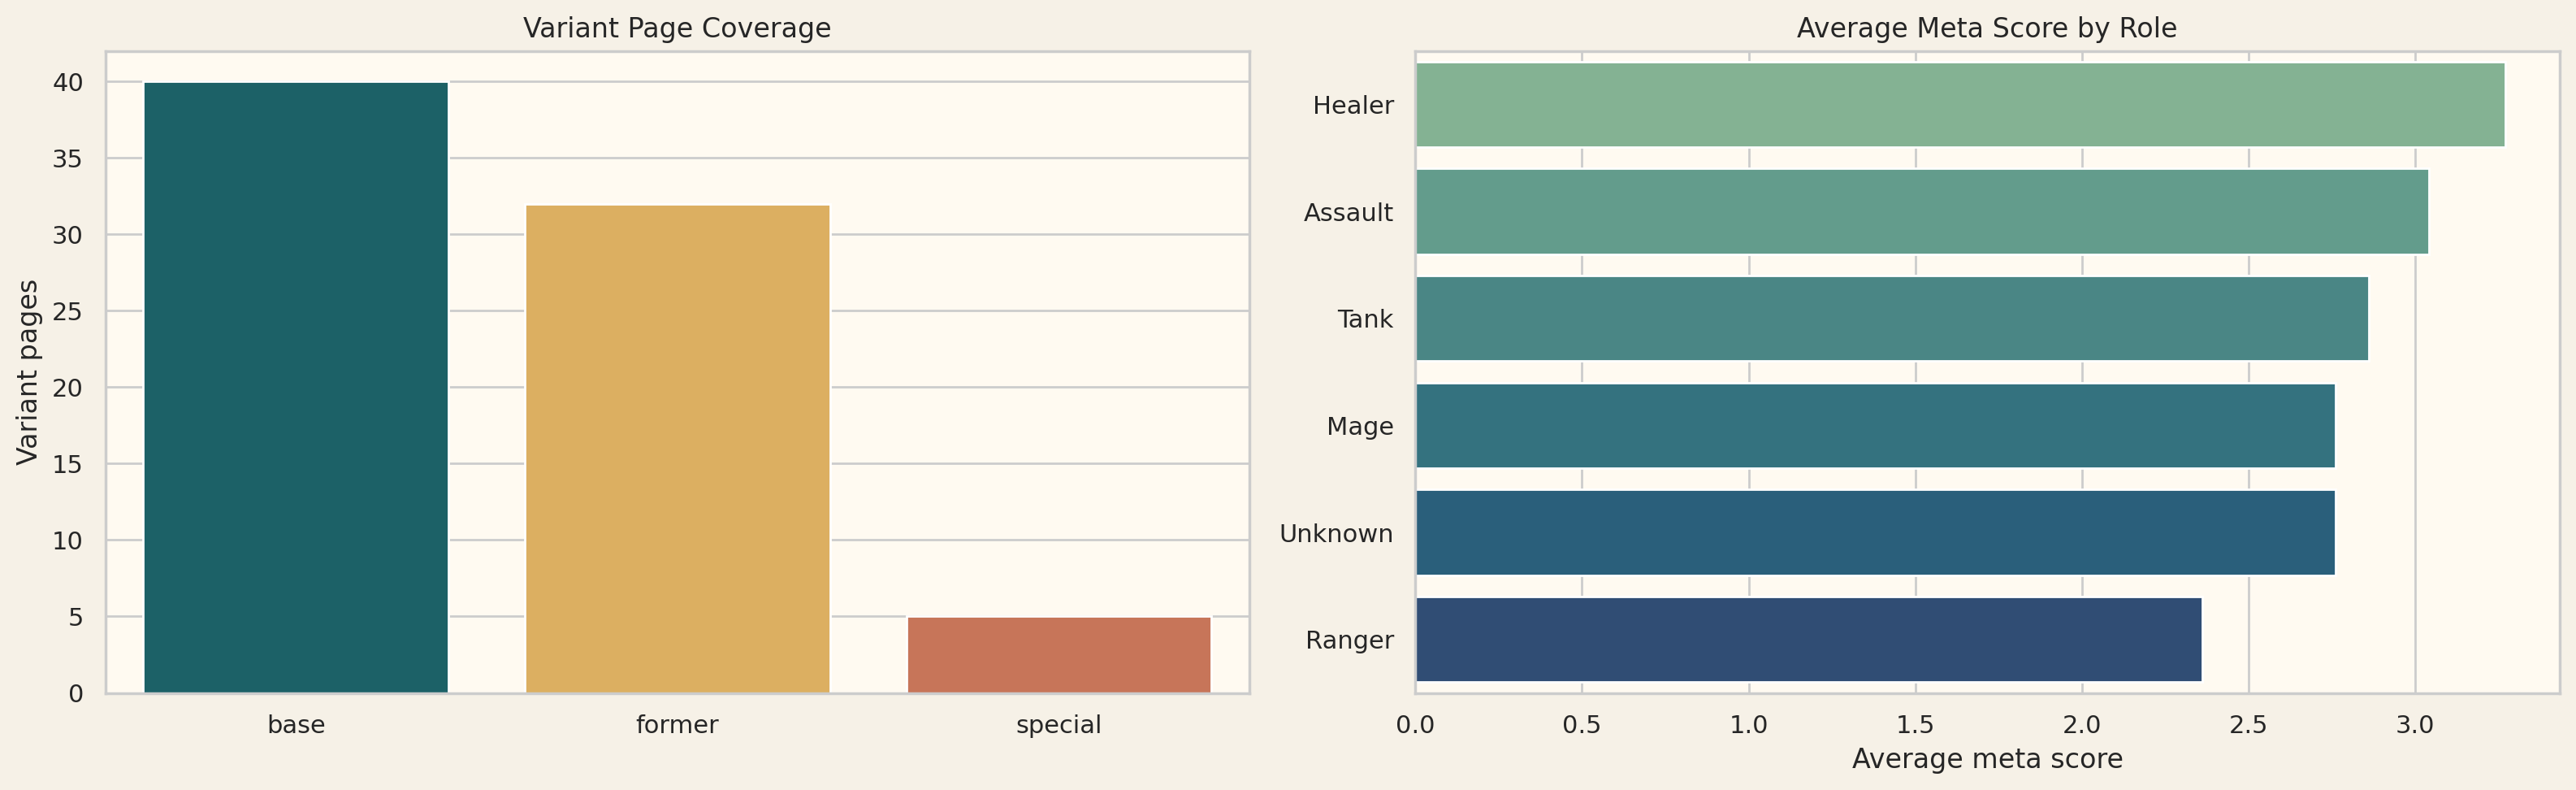

In [2]:
variant_mix_df = (
    variants_df.groupby("variant_kind", dropna=False)
    .size()
    .reset_index(name="variant_count")
    .sort_values("variant_count", ascending=False)
    .reset_index(drop=True)
)

section_coverage_df = (
    section_index_df.groupby("name_en", dropna=False)
    .agg(
        variants=("variant_title", "nunique"),
        section_blocks=("heading_title", "count"),
        patch_blocks=("section_path", lambda values: values.str.contains("Patch Details", case=False, na=False).sum()),
    )
    .reset_index()
    .sort_values(["section_blocks", "variants"], ascending=[False, False])
    .reset_index(drop=True)
)

gc_cards(
    "Overview Dashboard",
    "Use this pass to decide where to zoom in. The cards summarize coverage, the table shows the highest-ranked heroes, and the charts show how much of the roster and page history is currently captured.",
    [
        ("Top Score", heroes_df["final_meta_score"].max().round(2), "highest current meta score"),
        ("Median Score", heroes_df["final_meta_score"].median().round(2), "middle of the roster"),
        ("Variant Forms", len(variants_df), "base, former, and special pages"),
        ("Patch Coverage", len(patch_index_df), "captured patch detail blocks"),
    ],
)

display(gc_style(top_heroes_df, wide_columns=("name_en", "name_ko")))
display(gc_style(section_coverage_df.head(15)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=variant_mix_df,
    x="variant_kind",
    y="variant_count",
    palette=["#0f6c74", "#f0b44c", "#d96c47"],
    ax=axes[0],
)
axes[0].set_title("Variant Page Coverage")
axes[0].set_xlabel("")
axes[0].set_ylabel("Variant pages")

sns.barplot(
    data=role_summary_df,
    x="avg_meta_score",
    y="role",
    palette="crest",
    ax=axes[1],
)
axes[1].set_title("Average Meta Score by Role")
axes[1].set_xlabel("Average meta score")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 3. Search the Captured Pages

Set the filters in the next cell and rerun it whenever you want to find cooldowns, coefficients, SP costs, durations, patch changes, or specific effect text. This is the fastest path when you know roughly what you want but not where Namu stored it.

In [3]:
HERO_QUERY = "Ronan"
TEXT_QUERY = "seconds"
SECTION_QUERY = ""
KIND_QUERY = ""

filtered_sections = section_index_df.copy()
filtered_skills = skill_index_df.copy()
filtered_features = feature_index_df.copy()

if HERO_QUERY.strip():
    section_mask = filtered_sections["name_en"].str.contains(HERO_QUERY, case=False, na=False)
    section_mask = section_mask | filtered_sections["name_ko"].str.contains(HERO_QUERY, case=False, na=False)
    filtered_sections = filtered_sections[section_mask]

    skill_mask = filtered_skills["name_en"].str.contains(HERO_QUERY, case=False, na=False)
    filtered_skills = filtered_skills[skill_mask]

    feature_mask = filtered_features["name_en"].str.contains(HERO_QUERY, case=False, na=False)
    filtered_features = filtered_features[feature_mask]

if KIND_QUERY.strip():
    filtered_sections = filtered_sections[
        filtered_sections["variant_kind"].str.contains(KIND_QUERY, case=False, na=False)
    ]
    filtered_skills = filtered_skills[
        filtered_skills["variant_kind"].str.contains(KIND_QUERY, case=False, na=False)
    ]
    filtered_features = filtered_features[
        filtered_features["variant_kind"].str.contains(KIND_QUERY, case=False, na=False)
    ]

if SECTION_QUERY.strip():
    section_path_mask = filtered_sections["section_path"].str.contains(
        SECTION_QUERY, case=False, na=False
    )
    section_path_mask = section_path_mask | filtered_sections["heading_title"].str.contains(
        SECTION_QUERY, case=False, na=False
    )
    filtered_sections = filtered_sections[section_path_mask]

if TEXT_QUERY.strip():
    section_text_mask = filtered_sections["content"].str.contains(TEXT_QUERY, case=False, na=False)
    section_text_mask = section_text_mask | filtered_sections["heading_title"].str.contains(
        TEXT_QUERY, case=False, na=False
    )
    filtered_sections = filtered_sections[section_text_mask]

    skill_text_mask = filtered_skills["skill_name"].str.contains(TEXT_QUERY, case=False, na=False)
    skill_text_mask = skill_text_mask | filtered_skills["description"].str.contains(
        TEXT_QUERY, case=False, na=False
    )
    filtered_skills = filtered_skills[skill_text_mask]

    feature_text_mask = filtered_features["feature_value"].str.contains(TEXT_QUERY, case=False, na=False)
    feature_text_mask = feature_text_mask | filtered_features["feature_key"].str.contains(
        TEXT_QUERY, case=False, na=False
    )
    filtered_features = filtered_features[feature_text_mask]

display_variant_column = (
    "variant_label" if "variant_label" in filtered_sections.columns else "variant_kind"
 )

gc_cards(
    "Read-Only Search",
    f"Filters — hero: {HERO_QUERY or 'all'}, text: {TEXT_QUERY or 'all'}, section: {SECTION_QUERY or 'all'}, kind: {KIND_QUERY or 'all'}.",
    [
        ("Section Matches", len(filtered_sections), "matching heading blocks"),
        ("Skill Matches", len(filtered_skills), "parsed skill rows"),
        ("Feature Matches", len(filtered_features), "page capability markers"),
        ("Patch Matches", int(filtered_sections["section_path"].str.contains("Patch Details", case=False, na=False).sum()), "matching patch sections"),
    ],
)

if filtered_sections.empty:
    display(HTML("<p><strong>No matching section blocks.</strong> Change the filters and rerun the cell.</p>"))
else:
    section_preview_df = filtered_sections[
        ["name_en", display_variant_column, "heading_title", "section_path", "content"]
    ].copy()
    section_preview_df["content"] = section_preview_df["content"].str.replace(
        r"\s+", " ", regex=True
    ).str.slice(0, 320)
    display(gc_style(section_preview_df.head(25), wide_columns=("section_path", "content")))

if not filtered_skills.empty:
    skill_preview_df = filtered_skills[
        [
            "name_en",
            display_variant_column,
            "skill_stage",
            "skill_type",
            "skill_name",
            "description",
        ]
    ].copy()
    skill_preview_df["description"] = skill_preview_df["description"].str.replace(
        r"\s+", " ", regex=True
    ).str.slice(0, 220)
    display(gc_style(skill_preview_df.head(20), wide_columns=("description",)))

if not filtered_features.empty:
    feature_columns = ["name_en", display_variant_column, "feature_key", "feature_value"]
    feature_preview_df = filtered_features[feature_columns].copy()
    display(gc_style(feature_preview_df.head(20), wide_columns=("feature_value",)))

name_en,variant_label,heading_title,section_path,content
Ronan,Ronan · Base,pet,pet,"tempe skill name cool down explanation basic attack 1 second Attack 1 enemy. Attacks one enemy with a spear , inflicting 46% of physical attack damage. skill name cool down explanation warrior's shield 15 seconds Apply a shield to 2 allies and increase healing. Creates a shield equal to 15% of your maximum health for 6"
Ronan,Ronan · Base,2 Skill -Magic Defend,skill > 2 Skill -Magic Defend,⏰20 seconds SP 1 Dungeon Daejeon 〉 Magic Defend It instantly cancels harmful effects on party members and makes them invincible for 3 seconds to protect allies. (This skill cannot be reduced by more than 60%due to the reduction of skill reuse and reducing the remaining skill reuse. Patch Details 【Expand/Collapse】 Febru
Ronan,Ronan · Base,Chaser: Erudon's Demonic Sword,skill > Chaser: Erudon's Demonic Sword,"Dungeon Daejeon 〉 Erudon's sword Reinforcement Level 0/1/2/3 Based on During battle, summons a magic sword. When using 'Erudon's Horse Sword', the power of the sword is opened to the designated location, which causes 450%/526.4%/598.4%/675.2%of the physical damage , and is open for 15 seconds/20 seconds/25 seconds/30 s"
Ronan,Ronan · Base,Chaser: [Engraving] Erudon's Demonic Sword,Soul Imprint: Savior Ronan > Chaser: [Engraving] Erudon's Demonic Sword,"Dungeon Daejeon 〉 [Imprint] Erudon's sword Standards of the enhancement level of the soul, 1/2/3/4/5 [Permanent effect] When the party is guarded , the 'business' property party hero reduces the damage from 'life' attributes whenever the shield is taken . (Up to 60%) [Effect of Use] When the Erudon's Horse Sword is ope"
Ronan,Ronan · Base,Passive - Guardian,skill > Passive - Guardian,"Dungeon Daejeon 〉 Guardian Whenever Ronan receives damage from an enemy , he reduces the basic/skill damage party members receive from the enemy by 5% for 5 seconds, up to a maximum of 40% . (Decreases by 10% when using skill) Ronan summons the Tempest Blade, which is maintained for 5 seconds every time when he is dama"
Ronan,Ronan · Base,Passive - imprint of memory,Soul Imprint: Savior Ronan > Passive - imprint of memory,"Opening effect Dungeon Daejeon 〉 Traffic Standard 1/2/3/4/5 [Permanent effect] The basic attack is a 25%chance to create a shield of 20%/30%/40%/50%/60%for party members for 8 seconds. [engrave] Enhancement: Live +12,307, Physical Attack +2,769, Physical Defense +2,153, Magic Defense +2,615 The basic attack is strength"
Ronan,Ronan · Base,Skill 1 - Sword Lancer,skill > Skill 1 - Sword Lancer,"⏰ 15 seconds SP 1 Dungeon Daejeon 〉 Sword Lancer The party members are permanently generated by their maximum health of 45%, and at the same time, they apply the 60% reduction effect for 10 seconds, and then jump into the position designated as a huge window and shield, which causes 246% damage to the enemies and incre"
Ronan,Ronan · Base,Skill 1 - [Engraving] Sword Lancer,Soul Imprint: Savior Ronan > Skill 1 - [Engraving] Sword Lancer,"⏰ 15 seconds SP 1 Dungeon Daejeon 〉 [Imprint] Sodrancer Standard 1/2/3/4/5 For party members, they are permanently generated by their maximum health of 45%, and at the same time, they apply the 60%reduction effect of 10 seconds, and then jump into the designated location and develop a powerful magic circle to cause 246"
Ronan,Ronan · Base,Skill 2 - [Engraving] Magic Defend,Soul Imprint: Savior Ronan > Skill 2 - [Engraving] Magic Defend,"⏰20 seconds SP 1 Dungeon Daejeon 〉 [Imprint] Magic Defend Standard 1/2/3/4/5 [Permanent effect] If there are more than four 'business' attribute heroes to the party , they give the party hero the invincibility every 10 seconds for 3 seconds . [Effect of Use] The harmful effects of the party members instantaneously dism"
Ronan,Ronan · Base,Special Move - Tempest Barrier,skill > Special Move - Tempest Barrier,"special move ⏰30 seconds CP 20 Dungeon Daejeon 〉 Tempest Barrier With the power of the tempest, the enemies are 1,066% of the physical attacks and pr

name_en,variant_label,skill_stage,skill_type,skill_name,description
Ronan,Ronan · Base,base,chaser,Erudon's Demonic Sword,"Dungeon Daejeon 〉 Erudon's sword Reinforcement Level 0/1/2/3 Based on During battle, summons a magic sword. When using 'Erudon's Horse Sword', the power of the sword is opened to the designated location, which causes 450"
Ronan,Ronan · Base,base,passive,Guardian,"Dungeon Daejeon 〉 Guardian Whenever Ronan receives damage from an enemy , he reduces the basic/skill damage party members receive from the enemy by 5% for 5 seconds, up to a maximum of 40% . (Decreases by 10% when using"
Ronan,Ronan · Base,base,active,Magic Defend,⏰20 seconds SP 1 Dungeon Daejeon 〉 Magic Defend It instantly cancels harmful effects on party members and makes them invincible for 3 seconds to protect allies. (This skill cannot be reduced by more than 60%due to the re
Ronan,Ronan · Base,base,active,Sword Lancer,"⏰ 15 seconds SP 1 Dungeon Daejeon 〉 Sword Lancer The party members are permanently generated by their maximum health of 45%, and at the same time, they apply the 60% reduction effect for 10 seconds, and then jump into th"
Ronan,Ronan · Base,enhancement_i,chaser,Erudon's Demonic Sword,"Dungeon Daejeon 〉 Erudon's sword Reinforcement Level 0/1/2/3 Based on During battle, summons a magic sword. When using 'Erudon's Horse Sword', the power of the sword is opened to the designated location, which causes 450"
Ronan,Ronan · Base,enhancement_ii,chaser,Erudon's Demonic Sword,"Dungeon Daejeon 〉 Erudon's sword Reinforcement Level 0/1/2/3 Based on During battle, summons a magic sword. When using 'Erudon's Horse Sword', the power of the sword is opened to the designated location, which causes 450"
Ronan,Ronan · Base,imprint,chaser,[Engraving] Erudon's Demonic Sword,"Dungeon Daejeon 〉 [Imprint] Erudon's sword Standards of the enhancement level of the soul, 1/2/3/4/5 [Permanent effect] When the party is guarded , the 'business' property party hero reduces the damage from 'life' attrib"
Ronan,Ronan · Base,imprint,active,[Engraving] Magic Defend,"⏰20 seconds SP 1 Dungeon Daejeon 〉 [Imprint] Magic Defend Standard 1/2/3/4/5 [Permanent effect] If there are more than four 'business' attribute heroes to the party , they give the party hero the invincibility every 10 s"
Ronan,Ronan · Base,imprint,active,[Engraving] Sword Lancer,"⏰ 15 seconds SP 1 Dungeon Daejeon 〉 [Imprint] Sodrancer Standard 1/2/3/4/5 For party members, they are permanently generated by their maximum health of 45%, and at the same time, they apply the 60%reduction effect of 10"
Ronan,Ronan · Base,imprint,passive,imprint of memory,"Opening effect Dungeon Daejeon 〉 Traffic Standard 1/2/3/4/5 [Permanent effect] The basic attack is a 25%chance to create a shield of 20%/30%/40%/50%/60%for party members for 8 seconds. [engrave] Enhancement: Live +12,307"


## 4. Extra SQL Slices

Use this section when you want a more traditional table view of top heroes, role averages, and mode-specific rankings after you’ve already used the dashboard and search cells above.

In [4]:
top_heroes_query = """
SELECT
    h.hero_id,
    h.name_en,
    h.name_ko,
    h.role,
    h.rarity,
    s.base_score,
    s.final_meta_score,
    s.meta_rank
FROM heroes h
JOIN hero_meta_scores s USING (hero_id)
ORDER BY s.final_meta_score DESC
LIMIT 20
"""

top_heroes_df = pd.read_sql(top_heroes_query, conn)
role_summary_df = pd.read_sql(
    """
    SELECT
        role,
        COUNT(*) AS hero_count,
        ROUND(AVG(final_meta_score), 2) AS avg_meta_score,
        ROUND(MAX(final_meta_score), 2) AS best_meta_score
    FROM heroes
    JOIN hero_meta_scores USING (hero_id)
    GROUP BY role
    ORDER BY avg_meta_score DESC
    """,
    conn,
)
mode_breakdown_df = pd.read_sql(
    """
    SELECT
        hm.mode,
        h.name_en,
        h.role,
        hm.tier_letter,
        hm.tier_numeric,
        s.final_meta_score
    FROM hero_modes hm
    JOIN heroes h USING (hero_id)
    JOIN hero_meta_scores s USING (hero_id)
    ORDER BY hm.mode, hm.tier_numeric DESC, s.final_meta_score DESC
    """,
    conn,
)

display(top_heroes_df)
display(role_summary_df)
display(mode_breakdown_df.groupby("mode").head(10))

,hero_id,name_en,name_ko,role,rarity,base_score,final_meta_score,meta_rank
0,40,Ley,레이,Mage,SS,5.0,6.90,2
1,82,Amy,에이미,Healer,SS,5.0,6.90,1
2,1,Jin,진,Tank,SS,4.7,6.49,3
3,18,Elesis,엘리시스,Assault,SS,4.5,6.21,4
4,17,Lass,,Assault,S,5.0,6.04,5
5,19,Edel,에델,Assault,SS,4.2,5.80,6
6,20,Dio,디오,Assault,SS,4.1,5.66,9
7,83,Lime,라임,Healer,SS,4.1,5.66,7
8,84,Rin,린,Healer,SS,4.1,5.66,8
9,2,Ronan,로난,Tank,SS,3.9,5.38,10


,role,hero_count,avg_meta_score,best_meta_score
0,Healer,15,3.27,6.90
1,Assault,23,3.04,6.21
2,Tank,16,2.86,6.49
3,Unknown,24,2.76,2.76
4,Mage,23,2.76,6.90
5,Ranger,19,2.36,5.38


,mode,name_en,role,tier_letter,tier_numeric,final_meta_score
0,adventure,Ley,Mage,SS,5,6.90
1,adventure,Amy,Healer,SS,5,6.90
2,adventure,Jin,Tank,SS,5,6.49
3,adventure,Elesis,Assault,SS,5,6.21
4,adventure,Lass,Assault,SS,5,6.04
5,adventure,Ryan,Tank,SS,5,5.24
6,adventure,Edel,Assault,S,4,5.80
7,adventure,Dio,Assault,S,4,5.66
8,adventure,Lime,Healer,S,4,5.66
9,adventure,Rin,Healer,S,4,5.66


## 5. Charts and Exports

These charts are the broader roster view. Use them when you want distribution and comparison visuals instead of one-off search results.

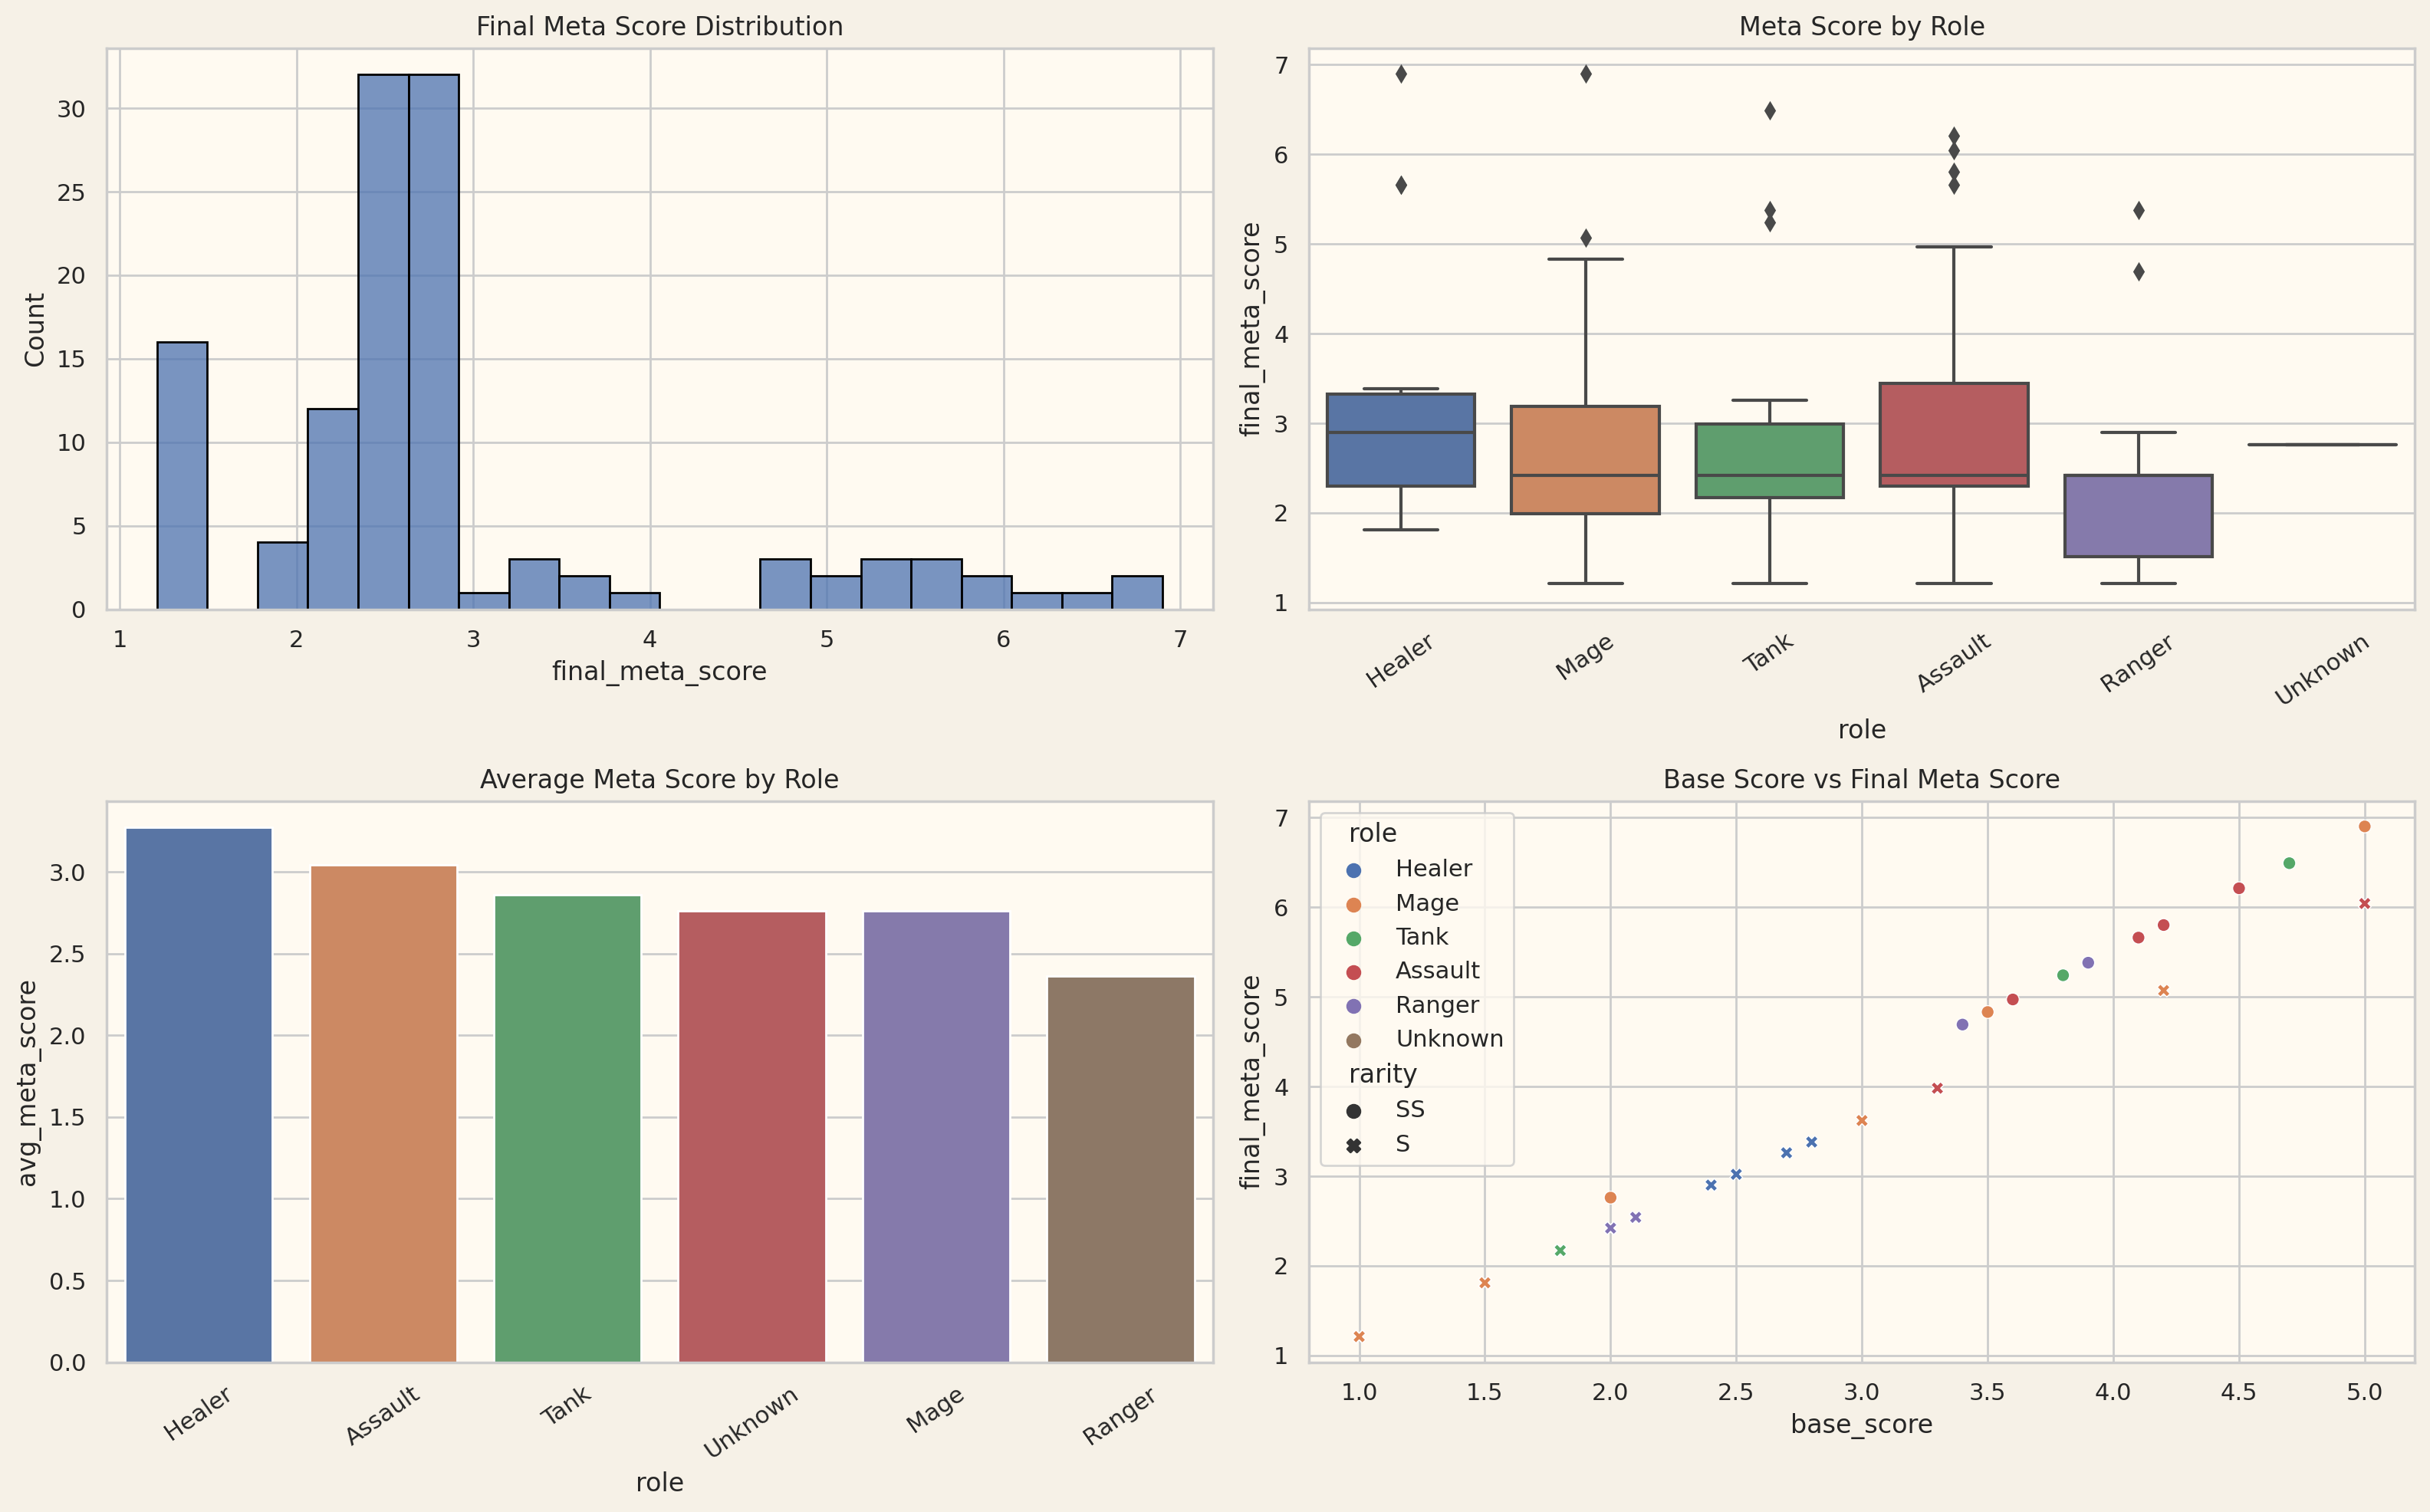

Exported:
/private/var/mobile/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/GCDC/data/processed/hero_leaderboard_from_notebook.csv
/private/var/mobile/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/GCDC/data/processed/top_heroes_from_notebook.csv
/private/var/mobile/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/GCDC/data/processed/mode_breakdown_from_notebook.csv
Closed SQLite connection: /private/var/mobile/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/GCDC/data/processed/grandchase.db


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(heroes_df["final_meta_score"], bins=20, ax=axes[0, 0], edgecolor="black")
axes[0, 0].set_title("Final Meta Score Distribution")

sns.boxplot(data=heroes_df, x="role", y="final_meta_score", ax=axes[0, 1])
axes[0, 1].set_title("Meta Score by Role")
axes[0, 1].tick_params(axis="x", rotation=35)

sns.barplot(data=role_summary_df, x="role", y="avg_meta_score", ax=axes[1, 0])
axes[1, 0].set_title("Average Meta Score by Role")
axes[1, 0].tick_params(axis="x", rotation=35)

sns.scatterplot(
    data=heroes_df,
    x="base_score",
    y="final_meta_score",
    hue="role",
    style="rarity",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Base Score vs Final Meta Score")

plt.tight_layout()
plt.show()

heroes_df.to_csv(PROCESSED_DIR / "hero_leaderboard_from_notebook.csv", index=False)
top_heroes_df.to_csv(PROCESSED_DIR / "top_heroes_from_notebook.csv", index=False)
mode_breakdown_df.to_csv(PROCESSED_DIR / "mode_breakdown_from_notebook.csv", index=False)

print("Exported:")
print(PROCESSED_DIR / "hero_leaderboard_from_notebook.csv")
print(PROCESSED_DIR / "top_heroes_from_notebook.csv")
print(PROCESSED_DIR / "mode_breakdown_from_notebook.csv")

conn.close()
print(f"Closed SQLite connection: {DB_PATH}")

## 6. Deep Explorer

This is the fuller browser for the captured section index. It reloads a self-contained explorer view and is useful if you want a second pass that focuses on raw page-section coverage.

In [6]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 220)

viz_candidates = [Path.cwd(), Path.cwd().parent]
VIZ_PROJECT_ROOT = next(
    candidate
    for candidate in viz_candidates
    if (candidate / "data" / "processed" / "grandchase.db").exists()
)
VIZ_DB_PATH = VIZ_PROJECT_ROOT / "data" / "processed" / "grandchase.db"
viz_conn = sqlite3.connect(VIZ_DB_PATH)

display(
    HTML(
        """
        <style>
            .gc-banner {
                background: linear-gradient(135deg, #0f4c5c 0%, #1d7874 45%, #f4c95d 100%);
                color: #f7f3e9;
                padding: 20px 24px;
                border-radius: 20px;
                margin: 12px 0 16px 0;
                box-shadow: 0 18px 45px rgba(15, 76, 92, 0.18);
            }
            .gc-banner h2 {
                margin: 0 0 6px 0;
                font-size: 1.8rem;
                font-weight: 700;
                letter-spacing: 0.01em;
            }
            .gc-banner p {
                margin: 0;
                max-width: 72ch;
                line-height: 1.55;
                color: rgba(247, 243, 233, 0.92);
            }
            .gc-card-grid {
                display: grid;
                grid-template-columns: repeat(auto-fit, minmax(180px, 1fr));
                gap: 12px;
                margin: 14px 0 20px 0;
            }
            .gc-card {
                background: linear-gradient(180deg, #fffaf1 0%, #f6eee1 100%);
                border: 1px solid #eadbc4;
                border-radius: 16px;
                padding: 14px 16px;
                box-shadow: 0 10px 26px rgba(99, 71, 45, 0.08);
            }
            .gc-label {
                font-size: 0.72rem;
                text-transform: uppercase;
                letter-spacing: 0.08em;
                color: #8c6a43;
                margin-bottom: 8px;
            }
            .gc-value {
                font-size: 1.9rem;
                font-weight: 800;
                color: #17324d;
                line-height: 1.1;
            }
            .gc-meta {
                margin-top: 6px;
                color: #5c6672;
                font-size: 0.9rem;
            }
        </style>
        """
    )
)


def gc_cards(title: str, subtitle: str, items: list[tuple[str, object, str]]) -> None:
    cards = "".join(
        f"<div class='gc-card'><div class='gc-label'>{label}</div><div class='gc-value'>{value}</div><div class='gc-meta'>{meta}</div></div>"
        for label, value, meta in items
    )
    display(
        HTML(
            f"<div class='gc-banner'><h2>{title}</h2><p>{subtitle}</p></div><div class='gc-card-grid'>{cards}</div>"
        )
    )


def gc_style(frame: pd.DataFrame, wide_columns: tuple[str, ...] = ()):
    if frame.empty:
        return frame

    styled = (
        frame.style.hide(axis="index")
        .set_table_styles(
            [
                {
                    "selector": "table",
                    "props": [
                        ("border-collapse", "separate"),
                        ("border-spacing", "0 6px"),
                        ("width", "100%"),
                        ("font-size", "0.96rem"),
                    ],
                },
                {
                    "selector": "thead th",
                    "props": [
                        ("background", "#17324d"),
                        ("color", "#f7f3e9"),
                        ("padding", "10px 12px"),
                        ("border", "0"),
                    ],
                },
                {
                    "selector": "tbody td",
                    "props": [
                        ("background", "#fffaf1"),
                        ("padding", "10px 12px"),
                        ("border-top", "1px solid #eadbc4"),
                        ("border-bottom", "1px solid #eadbc4"),
                        ("color", "#203040"),
                        ("vertical-align", "top"),
                    ],
                },
            ]
        )
    )

    if wide_columns:
        styled = styled.set_properties(
            subset=list(wide_columns),
            **{"white-space": "pre-wrap", "max-width": "520px"},
        )

    numeric_columns = [
        column for column in frame.columns if pd.api.types.is_numeric_dtype(frame[column])
    ]
    if numeric_columns:
        styled = styled.background_gradient(subset=numeric_columns, cmap="YlOrBr")
    return styled


section_index_df = pd.read_sql(
    """
    SELECT
        h.name_en,
        h.name_ko,
        hv.variant_id,
        hv.variant_kind,
        hv.variant_name_en,
        hv.source_title AS variant_title,
        hv.variant_suffix,
        hvs.heading_level,
        hvs.heading_title,
        hvs.section_path,
        hvs.content,
        hvs.source_page
    FROM hero_variant_sections hvs
    JOIN hero_variants hv ON hv.variant_id = hvs.variant_id
    JOIN heroes h ON h.hero_id = hv.hero_id
    ORDER BY h.name_en, hv.variant_kind, hvs.heading_level, hvs.heading_title
    """,
    viz_conn,
).fillna("")

skill_index_df = pd.read_sql(
    """
    SELECT
        h.name_en,
        hv.variant_kind,
        hv.source_title AS variant_title,
        hvs.section_title,
        hvs.skill_stage,
        hvs.skill_type,
        hvs.skill_name,
        hvs.description
    FROM hero_variant_skills hvs
    JOIN hero_variants hv ON hv.variant_id = hvs.variant_id
    JOIN heroes h ON h.hero_id = hv.hero_id
    ORDER BY h.name_en, hv.variant_kind, hvs.skill_stage, hvs.skill_name
    """,
    viz_conn,
).fillna("")

feature_index_df = pd.read_sql(
    """
    SELECT
        h.name_en,
        hv.variant_kind,
        hv.source_title AS variant_title,
        hvf.feature_key,
        hvf.feature_value
    FROM hero_variant_features hvf
    JOIN hero_variants hv ON hv.variant_id = hvf.variant_id
    JOIN heroes h ON h.hero_id = hv.hero_id
    ORDER BY h.name_en, hv.variant_kind, hvf.feature_key
    """,
    viz_conn,
).fillna("")

patch_index_df = section_index_df[
    section_index_df["section_path"].str.contains("Patch Details", case=False, na=False)
].copy()

gc_cards(
    "GrandChase Data Explorer",
    "This view is meant to replace raw CSV digging. It reads the stored SQLite outputs only and surfaces the full page-section capture, parsed skill rows, feature flags, and patch-note blocks in one place.",
    [
        ("Heroes", section_index_df["name_en"].nunique(), "heroes with captured variant data"),
        ("Variants", section_index_df["variant_title"].nunique(), "hero / form pages"),
        ("Section Blocks", len(section_index_df), "full heading blocks from Namu pages"),
        ("Skill Rows", len(skill_index_df), "parsed skill entries"),
        ("Patch Notes", len(patch_index_df), "section blocks with patch history"),
        ("Feature Flags", len(feature_index_df), "page capability markers"),
    ],
)

overview_preview_df = section_index_df[
    ["name_en", "variant_kind", "heading_title", "section_path", "content"]
].head(12).copy()
overview_preview_df["content"] = overview_preview_df["content"].str.replace(
    r"\s+", " ", regex=True
).str.slice(0, 180)

display(gc_style(overview_preview_df, wide_columns=("section_path", "content")))
print(f"Explorer connected to {VIZ_DB_PATH}")

name_en,variant_kind,heading_title,section_path,content
Ai,base,Avatar,Avatar,more details Ai (Grand Chase for kakao)/Avatar documentcastPlease note.
Ai,base,Soul Imprint: Galatea Child,Soul Imprint: Galatea Child,soul imprint illustrations
Ai,base,dedicated equipment,dedicated equipment,"Heaven's Key level magic attack power vitality physical defense magic defense 1 1,400 1,770 250 370 8 4,276 5,395 761 1,137 10 4,920 6,200 880 1,300 Encyclopedia Story An external"
Ai,base,digression,digression,"He is the SS-class hero, the first rotating attribute hero and the first artificial intelligence race after the attribute system update in Grand Chase Mobile. The name of the soul"
Ai,base,evaluation,evaluation,"It is a cycle magic hero with strong attack power. Although it is not yet Tier 1 due to the release of Bastet and Dea , it can be used in raids depending on the situation due to it"
Ai,base,list of lines,list of lines,Evolvable Please evolve . can be awakened Please wake up . Characteristic selectable Please check the properties . transcendence awakening possible I ask for transcendental awakeni
Ai,base,look around,look around,Major playable characters in the Grand Chase series [ Expand/Collapse ] grand chase crew M P Elesis PC / Mobile lire PC / Mobile Arme PC / Mobile Lars PC / Mobile Ryan PC / Mobile
Ai,base,outline,outline,width=100% In -game loading screen “My name is Ai. It’s an honor to meet you!” Grand Chase (Mobile) SS grade magical hero.
Ai,base,pet,pet,"waley skill name cool down explanation basic attack 1 second Inflicts damage on 1 enemy. Deals 85% of magic attack damage to one nearby enemy . When starting a battle with 'I' , in"
Ai,base,profile,profile,"Artificial intelligence takes the first step on a journey, leaving behind a thousand years of waiting In the past, the kingdom of Kounat was directly ruled by the three goddesses w"


Explorer connected to /private/var/mobile/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/GCDC/data/processed/grandchase.db


In [ ]:
# Refresh the deep explorer tables with the same variant labels.
variant_lookup_source = (
    variants_df[["variant_title", "variant_name_en", "variant_kind", "variant_suffix"]]
    .drop_duplicates()
    if "variants_df" in globals()
    else section_index_df.assign(
        variant_suffix=section_index_df["variant_kind"]
        .map({"former": "T", "special": "S"})
        .fillna("")
    )[["variant_title", "variant_name_en", "variant_kind", "variant_suffix"]].drop_duplicates()
)

deep_variant_name_lookup = variant_lookup_source.set_index(
    ["variant_title", "variant_kind"]
)["variant_name_en"].to_dict()
deep_variant_suffix_lookup = variant_lookup_source.set_index(
    ["variant_title", "variant_kind"]
)["variant_suffix"].to_dict()


def apply_deep_variant_display_columns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    if "variant_name_en" not in result.columns:
        result["variant_name_en"] = [
            deep_variant_name_lookup.get((title, kind), title)
            for title, kind in zip(result["variant_title"], result["variant_kind"])
        ]
    else:
        result["variant_name_en"] = [
            str(name).strip() or deep_variant_name_lookup.get((title, kind), title)
            for name, title, kind in zip(
                result["variant_name_en"],
                result["variant_title"],
                result["variant_kind"],
            )
        ]

    result["variant_suffix"] = [
        deep_variant_suffix_lookup.get((title, kind), "")
        for title, kind in zip(result["variant_title"], result["variant_kind"])
]
    result["variant_kind_label"] = [
        format_variant_kind_label(kind, suffix)
        for kind, suffix in zip(result["variant_kind"], result["variant_suffix"])
    ]
    result["variant_label"] = [
        f"{name} · {kind_label}"
        for name, kind_label in zip(
            result["variant_name_en"],
            result["variant_kind_label"],
        )
    ]
    return result


section_index_df = apply_deep_variant_display_columns(section_index_df)
skill_index_df = apply_deep_variant_display_columns(skill_index_df)
feature_index_df = apply_deep_variant_display_columns(feature_index_df)

overview_preview_df = section_index_df[
    ["name_en", "variant_label", "heading_title", "section_path", "content"]
] .head(12).copy()
overview_preview_df["content"] = overview_preview_df["content"].str.replace(
    r"\s+", " ", regex=True
).str.slice(0, 180)

display(gc_style(overview_preview_df, wide_columns=("section_path", "content")))
display(
    HTML(
        "<p><strong>Deep explorer labels refreshed.</strong> Former pages now show (T) and special pages show (S) in the preview tables below.</p>"
    )
)

## 7. Focused Section Search

Use these filters when you already know the keyword you care about and want to search the deeper explorer directly.

In [ ]:
HERO_QUERY = "Ronan"
TEXT_QUERY = "seconds"
SECTION_QUERY = ""
KIND_QUERY = ""

filtered_sections = section_index_df.copy()

if HERO_QUERY.strip():
    hero_mask = filtered_sections["name_en"].str.contains(HERO_QUERY, case=False, na=False)
    hero_mask = hero_mask | filtered_sections["name_ko"].str.contains(HERO_QUERY, case=False, na=False)
    filtered_sections = filtered_sections[hero_mask]

if KIND_QUERY.strip():
    filtered_sections = filtered_sections[
        filtered_sections["variant_kind"].str.contains(KIND_QUERY, case=False, na=False)
    ]

if SECTION_QUERY.strip():
    section_mask = filtered_sections["section_path"].str.contains(
        SECTION_QUERY, case=False, na=False
    )
    section_mask = section_mask | filtered_sections["heading_title"].str.contains(
        SECTION_QUERY, case=False, na=False
    )
    filtered_sections = filtered_sections[section_mask]

if TEXT_QUERY.strip():
    text_mask = filtered_sections["content"].str.contains(TEXT_QUERY, case=False, na=False)
    text_mask = text_mask | filtered_sections["heading_title"].str.contains(
        TEXT_QUERY, case=False, na=False
    )
    filtered_sections = filtered_sections[text_mask]

display_variant_column = (
    "variant_label" if "variant_label" in filtered_sections.columns else "variant_kind"
 )

gc_cards(
    "Section Search",
    f"Current filters — hero: {HERO_QUERY or 'all'}, text: {TEXT_QUERY or 'all'}, section: {SECTION_QUERY or 'all'}, kind: {KIND_QUERY or 'all'}.",
    [
        ("Matches", len(filtered_sections), "section blocks"),
        ("Heroes", filtered_sections["name_en"].nunique(), "unique heroes"),
        ("Variants", filtered_sections["variant_title"].nunique(), "matching pages"),
        (
            "Patch Notes",
            int(filtered_sections["section_path"].str.contains("Patch Details", case=False, na=False).sum()),
            "matching patch sections",
        ),
    ],
)

if filtered_sections.empty:
    display(HTML("<p><strong>No matching section blocks.</strong> Adjust the filters and rerun the cell.</p>"))
else:
    preview_df = filtered_sections[
        ["name_en", display_variant_column, "heading_title", "section_path", "content"]
    ].copy()
    preview_df["content"] = preview_df["content"].str.replace(r"\s+", " ", regex=True).str.slice(0, 340)
    display(gc_style(preview_df.head(40), wide_columns=("section_path", "content")))

name_en,variant_kind,heading_title,section_path,content
Ronan,base,pet,pet,"tempe skill name cool down explanation basic attack 1 second Attack 1 enemy. Attacks one enemy with a spear , inflicting 46% of physical attack damage. skill name cool down explanation warrior's shield 15 seconds Apply a shield to 2 allies and increase healing. Creates a shield equal to 15% of your maximum health for 6 seconds for the two"
Ronan,base,2 Skill -Magic Defend,skill > 2 Skill -Magic Defend,"⏰20 seconds SP 1 Dungeon Daejeon 〉 Magic Defend It instantly cancels harmful effects on party members and makes them invincible for 3 seconds to protect allies. (This skill cannot be reduced by more than 60%due to the reduction of skill reuse and reducing the remaining skill reuse. Patch Details 【Expand/Collapse】 February 7, 2018 Buff : R"
Ronan,base,Chaser: Erudon's Demonic Sword,skill > Chaser: Erudon's Demonic Sword,"Dungeon Daejeon 〉 Erudon's sword Reinforcement Level 0/1/2/3 Based on During battle, summons a magic sword. When using 'Erudon's Horse Sword', the power of the sword is opened to the designated location, which causes 450%/526.4%/598.4%/675.2%of the physical damage , and is open for 15 seconds/20 seconds/25 seconds/30 seconds . [Magic Swor"
Ronan,base,Chaser: [Engraving] Erudon's Demonic Sword,Soul Imprint: Savior Ronan > Chaser: [Engraving] Erudon's Demonic Sword,"Dungeon Daejeon 〉 [Imprint] Erudon's sword Standards of the enhancement level of the soul, 1/2/3/4/5 [Permanent effect] When the party is guarded , the 'business' property party hero reduces the damage from 'life' attributes whenever the shield is taken . (Up to 60%) [Effect of Use] When the Erudon's Horse Sword is opened, 15 'Judgment of"
Ronan,base,Passive - Guardian,skill > Passive - Guardian,"Dungeon Daejeon 〉 Guardian Whenever Ronan receives damage from an enemy , he reduces the basic/skill damage party members receive from the enemy by 5% for 5 seconds, up to a maximum of 40% . (Decreases by 10% when using skill) Ronan summons the Tempest Blade, which is maintained for 5 seconds every time when he is damaged by the enemy and"
Ronan,base,Passive - imprint of memory,Soul Imprint: Savior Ronan > Passive - imprint of memory,"Opening effect Dungeon Daejeon 〉 Traffic Standard 1/2/3/4/5 [Permanent effect] The basic attack is a 25%chance to create a shield of 20%/30%/40%/50%/60%for party members for 8 seconds. [engrave] Enhancement: Live +12,307, Physical Attack +2,769, Physical Defense +2,153, Magic Defense +2,615 The basic attack is strengthened during the impr"
Ronan,base,Skill 1 - Sword Lancer,skill > Skill 1 - Sword Lancer,"⏰ 15 seconds SP 1 Dungeon Daejeon 〉 Sword Lancer The party members are permanently generated by their maximum health of 45%, and at the same time, they apply the 60% reduction effect for 10 seconds, and then jump into the position designated as a huge window and shield, which causes 246% damage to the enemies and increases the magic attac"
Ronan,base,Skill 1 - [Engraving] Sword Lancer,Soul Imprint: Savior Ronan > Skill 1 - [Engraving] Sword Lancer,"⏰ 15 seconds SP 1 Dungeon Daejeon 〉 [Imprint] Sodrancer Standard 1/2/3/4/5 For party members, they are permanently generated by their maximum health of 45%, and at the same time, they apply the 60%reduction effect of 10 seconds, and then jump into the designated location and develop a powerful magic circle to cause 246%damage to physical"
Ronan,base,Skill 2 - [Engraving] Magic Defend,Soul Imprint: Savior Ronan > Skill 2 - [Engraving] Magic Defend,"⏰20 seconds SP 1 Dungeon Daejeon 〉 [Imprint] Magic Defend Standard 1/2/3/4/5 [Permanent effect] If there are more than four 'business' attribute heroes to the party , they give the party hero the invincibility every 10 seconds for 3 seconds . [Effect of Use] The harmful effects of the party members instantaneously dismissed and invincible"
Ronan,base,Special Move - Tempest Barrier,skill > Special Move - Tempest Barrier,"special move ⏰30 seconds CP 20 Dungeon Daejeon 〉 

## 8. Hero Dossier

This is the single-hero view: variants, feature flags, parsed skills, patch snippets, and quick charts for one character at a time.

variant_label,feature_key,feature_value
Ronan · Base,characteristics,Characteristic selectable
Ronan · Base,transcendental_awakening,transcendental awakening possible


variant_label,skill_stage,skill_type,skill_name,description
Ronan · Base,base,chaser,Erudon's Demonic Sword,"Dungeon Daejeon 〉 Erudon's sword Reinforcement Level 0/1/2/3 Based on During battle, summons a magic sword. When using 'Erudon's Horse Sword', the power of the sword is opened to the designated location, which causes 450%/526.4%/598.4%/675.2%of the physical da"
Ronan · Base,base,passive,Guardian,"Dungeon Daejeon 〉 Guardian Whenever Ronan receives damage from an enemy , he reduces the basic/skill damage party members receive from the enemy by 5% for 5 seconds, up to a maximum of 40% . (Decreases by 10% when using skill) Ronan summons the Tempest Blade,"
Ronan · Base,base,active,Magic Defend,⏰20 seconds SP 1 Dungeon Daejeon 〉 Magic Defend It instantly cancels harmful effects on party members and makes them invincible for 3 seconds to protect allies. (This skill cannot be reduced by more than 60%due to the reduction of skill reuse and reducing the
Ronan · Base,base,active,Sword Lancer,"⏰ 15 seconds SP 1 Dungeon Daejeon 〉 Sword Lancer The party members are permanently generated by their maximum health of 45%, and at the same time, they apply the 60% reduction effect for 10 seconds, and then jump into the position designated as a huge window a"
Ronan · Base,enhancement_i,chaser,Erudon's Demonic Sword,"Dungeon Daejeon 〉 Erudon's sword Reinforcement Level 0/1/2/3 Based on During battle, summons a magic sword. When using 'Erudon's Horse Sword', the power of the sword is opened to the designated location, which causes 450%/526.4%/598.4%/675.2%of the physical da"
Ronan · Base,enhancement_ii,chaser,Erudon's Demonic Sword,"Dungeon Daejeon 〉 Erudon's sword Reinforcement Level 0/1/2/3 Based on During battle, summons a magic sword. When using 'Erudon's Horse Sword', the power of the sword is opened to the designated location, which causes 450%/526.4%/598.4%/675.2%of the physical da"
Ronan · Base,imprint,chaser,[Engraving] Erudon's Demonic Sword,"Dungeon Daejeon 〉 [Imprint] Erudon's sword Standards of the enhancement level of the soul, 1/2/3/4/5 [Permanent effect] When the party is guarded , the 'business' property party hero reduces the damage from 'life' attributes whenever the shield is taken . (Up"
Ronan · Base,imprint,active,[Engraving] Magic Defend,"⏰20 seconds SP 1 Dungeon Daejeon 〉 [Imprint] Magic Defend Standard 1/2/3/4/5 [Permanent effect] If there are more than four 'business' attribute heroes to the party , they give the party hero the invincibility every 10 seconds for 3 seconds . [Effect of Use] T"
Ronan · Base,imprint,active,[Engraving] Sword Lancer,"⏰ 15 seconds SP 1 Dungeon Daejeon 〉 [Imprint] Sodrancer Standard 1/2/3/4/5 For party members, they are permanently generated by their maximum health of 45%, and at the same time, they apply the 60%reduction effect of 10 seconds, and then jump into the designat"
Ronan · Base,imprint,passive,imprint of memory,"Opening effect Dungeon Daejeon 〉 Traffic Standard 1/2/3/4/5 [Permanent effect] The basic attack is a 25%chance to create a shield of 20%/30%/40%/50%/60%for party members for 8 seconds. [engrave] Enhancement: Live +12,307, Physical Attack +2,769, Physical Defen"


,variant_label,heading_title,content


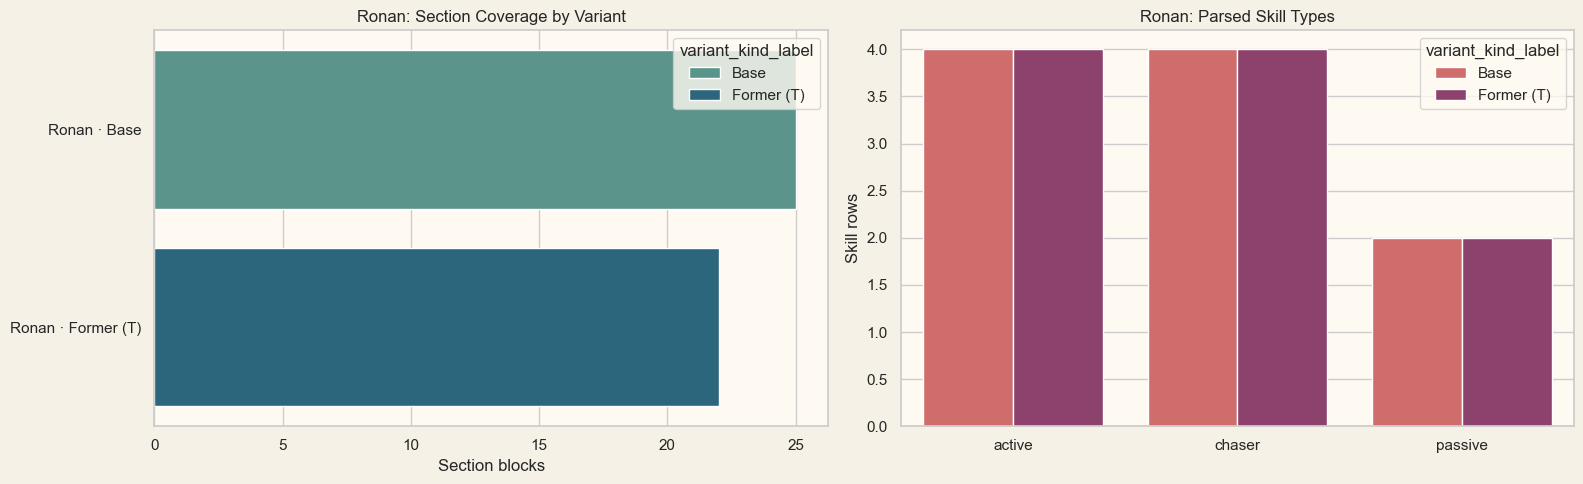

In [4]:
FOCUS_HERO = "Ronan"

hero_sections_df = section_index_df[
    section_index_df["name_en"].str.contains(FOCUS_HERO, case=False, na=False)
] .copy()
hero_skills_df = skill_index_df[
    skill_index_df["name_en"].str.contains(FOCUS_HERO, case=False, na=False)
] .copy()
hero_features_df = feature_index_df[
    feature_index_df["name_en"].str.contains(FOCUS_HERO, case=False, na=False)
] .copy()

if hero_sections_df.empty:
    raise ValueError(f"No captured section data found for hero filter: {FOCUS_HERO}")

hero_patch_df = hero_sections_df[
    hero_sections_df["section_path"].str.contains("Patch Details", case=False, na=False)
] .copy()

display_variant_column = (
    "variant_label" if "variant_label" in hero_sections_df.columns else "variant_title"
 )
hue_variant_column = (
    "variant_kind_label" if "variant_kind_label" in hero_sections_df.columns else "variant_kind"
 )

gc_cards(
    f"Hero Dossier: {FOCUS_HERO}",
    "This pulls directly from the stored page-section capture and parsed skill rows so you can browse one hero without opening the raw Namu pages.",
    [
        ("Variants", hero_sections_df["variant_title"].nunique(), "captured pages"),
        ("Sections", len(hero_sections_df), "page section blocks"),
        ("Skills", len(hero_skills_df), "parsed skill rows"),
        ("Feature Flags", len(hero_features_df), "capability markers"),
        ("Patch Blocks", len(hero_patch_df), "patch-note sections"),
    ],
)

feature_preview_df = hero_features_df[
    [display_variant_column, "feature_key", "feature_value"]
] .copy()
skill_preview_df = hero_skills_df[
    [display_variant_column, "skill_stage", "skill_type", "skill_name", "description"]
] .copy()
skill_preview_df["description"] = skill_preview_df["description"].str.replace(
    r"\s+", " ", regex=True
).str.slice(0, 260)
patch_preview_df = hero_patch_df[[display_variant_column, "heading_title", "content"]].copy()
patch_preview_df["content"] = patch_preview_df["content"].str.replace(r"\s+", " ", regex=True).str.slice(0, 260)

display(gc_style(feature_preview_df, wide_columns=("feature_value",)))
display(gc_style(skill_preview_df.head(30), wide_columns=(display_variant_column, "description")))
display(gc_style(patch_preview_df.head(20), wide_columns=("content",)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

section_counts_df = hero_sections_df.groupby([hue_variant_column, display_variant_column]).size().reset_index(name="section_blocks")
sns.barplot(
    data=section_counts_df,
    x="section_blocks",
    y=display_variant_column,
    hue=hue_variant_column,
    palette="crest",
    ax=axes[0],
)
axes[0].set_title(f"{FOCUS_HERO}: Section Coverage by Variant")
axes[0].set_xlabel("Section blocks")
axes[0].set_ylabel("")

skill_counts_df = hero_skills_df.groupby([hue_variant_column, "skill_type"]).size().reset_index(name="skill_count")
sns.barplot(
    data=skill_counts_df,
    x="skill_type",
    y="skill_count",
    hue=hue_variant_column,
    palette="flare",
    ax=axes[1],
)
axes[1].set_title(f"{FOCUS_HERO}: Parsed Skill Types")
axes[1].set_xlabel("")
axes[1].set_ylabel("Skill rows")

plt.tight_layout()
plt.show()